## Distribuição de Exponencial

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import expon
sns.set_theme(style="whitegrid")

#a média1 é igual ao desvio padrão... oq isso significa???

Vamos começar simulando o tempo de espera até a chegada do próximo cliente a um caixa eletrônico.

O caixa recebe, em média, 3,6 clientes a cada 10 minutos. Portanto, o tempo médio entre chegadas é de aproximadamente 2,78 minutos.

Vamos utilizar a distribuição Exponencial para gerar tempos de espera aleatórios.

In [1]:
lamb = 3.6/10
media = 1/lamb
media

2.7777777777777777

Há um detalhe importante que merece destaque: o NumPy utiliza o parâmetro scale, que corresponde à média da distribuição, e não à taxa λ. Assim, scale = 1/λ.

Vamos gerar um tempo de espera.

In [97]:
np.random.exponential(scale=media, size = 10)

array([1.42439039, 0.72075707, 0.49214121, 2.94937843, 0.34090239,
       3.62357169, 2.88880844, 6.76144961, 2.2655119 , 5.63800351])

Agora, vamos gerar 10 tempos de espera.

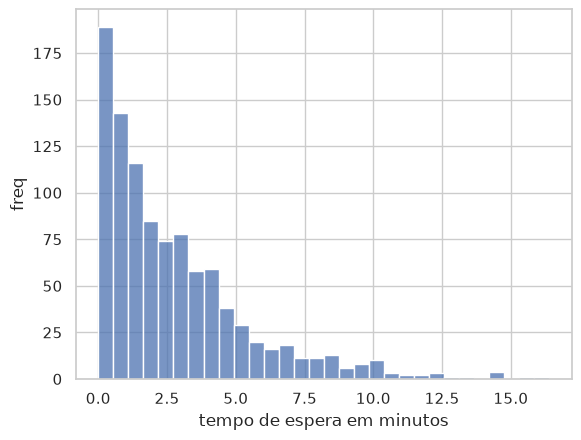

In [98]:
tempos = np.random.exponential(scale=media, size = 1000)
sns.histplot(tempos, bins=30)
plt.xlabel('tempo de espera em minutos')
plt.ylabel('freq')
plt.show()

Vamos agora gerar 1.000 tempos de espera e plotar um gráfico mostrando o resultado.

In [99]:
expon.cdf(5, scale=media)

np.float64(0.8347011117784134)

Um caixa eletrônico recebe, em média, 3,6 clientes a cada 10 minutos. Qual é a probabilidade de que o próximo cliente chegue em menos de 5 minutos?


In [100]:
expon.cdf(5,scale=media)

np.float64(0.8347011117784134)

expon.cdf(k, scale) - Cumulative distribution function - igual ou menos que \
expon.pdf(k, scale) - Probability density function - para o valor exato \
expon.sf(k, scale) - Para mais que (similar a 1 - cdf) \
expon.mean(k, scale) - Para a média da distribuição \
expon.var(k scale) - Para a variância da distribuição \
expon.std(k, scale) - Para o desvio padrão da distribuição

Qual é a probabilidade do tempo de espera ser superior a 5 minutos? 

In [101]:
expon.sf(5,scale=media)


np.float64(0.16529888822158653)

E a probabilidade de que o próximo cliente chegue entre 2 e 5 minutos?

In [102]:
expon.cdf(5,scale=media) - expon.cdf(2,scale=media)



np.float64(0.3214533677383852)

Vejamos agora o cálculo da média, variância e desvio padrão.

In [103]:
expon.mean(scale=media)

np.float64(2.7777777777777777)

In [104]:
expon.var(scale=media)

np.float64(7.716049382716049)

In [105]:
expon.std(scale=media)

np.float64(2.7777777777777777)

Vamos agora plotar um gráfico mostrando as probabilidades de termos um tempo de espera de 0, 1, 2, ... 15 minutos até a chegada da próxima pessoa. Para tanto, inicialmente geramos um vetor de 0 .. 15 para representar o eixo x e depois geramos outro vetor contendo as probabilidades equivalentes para cada valor do primeiro vetor.

<Axes: >

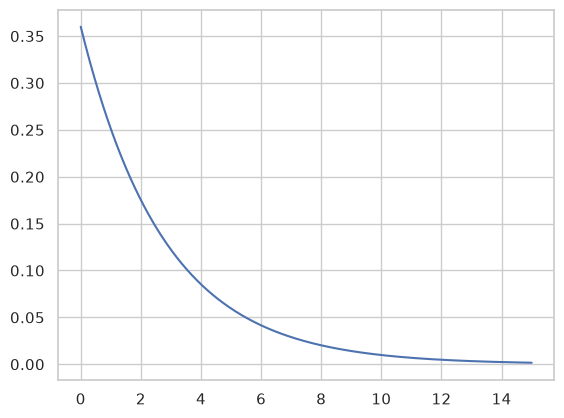

In [106]:
eixo_x = np.linspace(0,15,1000)
eixo_y = expon.pdf(eixo_x, scale=media)

sns.lineplot(x=eixo_x, y=eixo_y)

Vejamos agora o gráfico da probabilidade acumulada.

<Axes: >

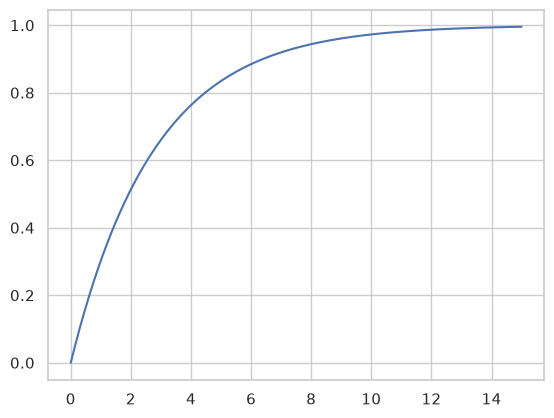

In [107]:
eixo_x = np.linspace(0,15,1000)
eixo_y = expon.cdf(eixo_x, scale=media)

sns.lineplot(x=eixo_x, y=eixo_y)

Vamos utilizar os 1.000 tempos de espera simulados anteriormente para calcular a proporção de clientes que chegaram em menos de 5 minutos.

In [108]:
#probabilidade teórica
p_teorica = expon.cdf(5, scale=media)

#freqncia relativa observada

p_simulada = np.mean(tempos < 5)

print(p_teorica, p_simulada)

0.8347011117784134 0.845


Agora, vamos repetir o experimento utilizando 100.000 valores.

In [109]:
tempos = np.random.exponential(scale=media, size = 100000)
p_simulada = np.mean(tempos < 5)
print(p_teorica, p_simulada)

0.8347011117784134 0.83435


### Exercício 1
Uma central telefônica recebe, em média, 6 chamadas por hora. Considere que as chamadas seguem um processo de Poisson homogêneo.

a) Qual é o tempo médio de espera entre duas chamadas consecutivas?

b) Qual é a probabilidade de que a próxima chamada ocorra em menos de 5 minutos?

c) Qual é a probabilidade de que o tempo de espera ultrapasse 15 minutos?

In [110]:
media=60/6
print(media)

10.0


In [111]:
expon.cdf(5,scale=media)

np.float64(0.3934693402873666)

In [112]:
expon.sf(15,scale=media)

np.float64(0.22313016014842982)

### Exercício 2
O tempo de resposta de determinado serviço segue uma distribuição Exponencial com média de 200 milissegundos.

a) Qual é o valor do parâmetro λ, considerando o tempo em milissegundos?

b) Qual é a probabilidade de que uma requisição seja respondida em menos de 100 milissegundos?

c) Qual é a probabilidade de que o tempo de resposta esteja entre 100 e 300 milissegundos?

d) Construa um gráfico da função densidade de probabilidade.

In [113]:
print(1/200)
media = 200

0.005


In [114]:
expon.cdf(100,scale=media)

np.float64(0.3934693402873666)

In [115]:
expon.cdf(300) - expon.cdf(100,scale=media)

np.float64(0.6065306597126334)

<Axes: >

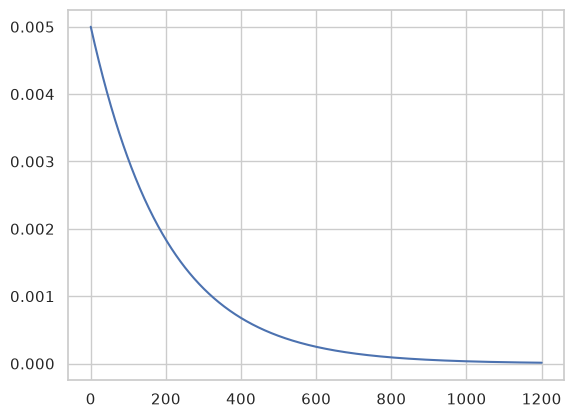

In [116]:
eixo_x = np.linspace(0,1200,1000)
eixo_y = expon.pdf(eixo_x, scale=media)

sns.lineplot(x=eixo_x, y=eixo_y)

### Exercício 3
Um sistema recebe, em média, 12 requisições por minuto, seguindo um processo de Poisson homogêneo.

a) Gere 10.000 tempos de espera entre requisições consecutivas.

b) Construa um histograma dos valores simulados.

c) Calcule a média e o desvio-padrão dos tempos simulados.

d) Compare os resultados obtidos com os valores teóricos da distribuição.

e) Calcule a proporção de tempos de espera inferiores a 3 segundos e compare com a probabilidade teórica.

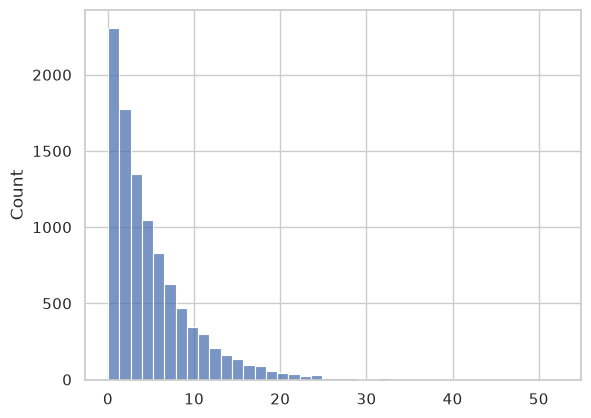

In [ ]:

media = 60/12
rng = np.random.default_rng(42)
tempos = np.random.exponential(scale=media, size=10000)
sns.histplot(tempos, bins=40)
plt.show()


In [125]:
print(np.std(tempos))
print(np.mean(tempos))

print(media)

5.063018778475657
5.004259425762
5.0


In [126]:
p_simulada = np.mean(tempos < 3)
print(p_simulada, expon.cdf(3, scale=media))

0.4497 0.4511883639059736


### Exercício 4
Um sistema recebe, em média, 4 requisições por minuto, seguindo um processo de Poisson homogêneo.

Determine o tempo máximo de espera t para o qual existe uma probabilidade de 95% de que a próxima requisição ocorra até esse instante.

Construa um gráfico da distribuição, indicando o tempo encontrado.

In [120]:
media = 4
expon.ppf(0.95, scale=media)

np.float64(11.98292909421596)

<Axes: >

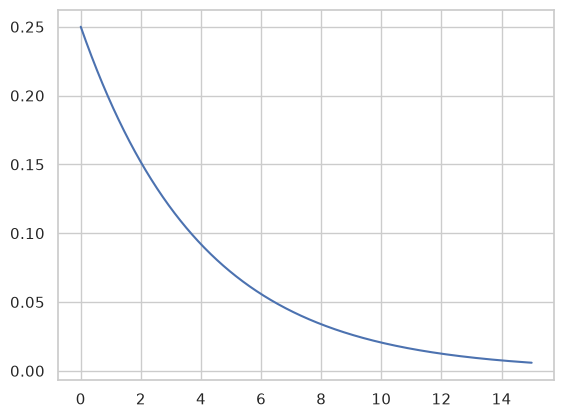

In [121]:
eixo_x = np.linspace(0,15,1000)
eixo_y = expon.pdf(eixo_x, scale=media)

sns.lineplot(x=eixo_x, y=eixo_y)